# Census Income Classification: Binary Income Prediction

## Import Libraries

In [96]:
import sys
from pathlib import Path

# Add src to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root / 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import pickle

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE

from sklearn.metrics import (
    classification_report, roc_auc_score, confusion_matrix,
    average_precision_score, f1_score, precision_recall_curve
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from utils import setup_logger, get_project_paths, ensure_path_exists

# Setup
logger = setup_logger(__name__)
paths = get_project_paths()
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

import warnings
warnings.filterwarnings('ignore')

logger.info("Classification Pipeline Starting")


# Paths
cwd = Path.cwd().resolve()
if (cwd / "data" / "processed").exists():
    processed_dir = cwd / "data" / "processed"
else:
    processed_dir = cwd.parent / "data" / "processed"

2026-04-18 20:46:26 - __main__ - INFO - Classification Pipeline Starting
2026-04-18 20:46:26 - __main__ - INFO - Classification Pipeline Starting
2026-04-18 20:46:26 - __main__ - INFO - Classification Pipeline Starting
2026-04-18 20:46:26 - __main__ - INFO - Classification Pipeline Starting
2026-04-18 20:46:26 - __main__ - INFO - Classification Pipeline Starting
2026-04-18 20:46:26 - __main__ - INFO - Classification Pipeline Starting
2026-04-18 20:46:26 - __main__ - INFO - Classification Pipeline Starting
2026-04-18 20:46:26 - __main__ - INFO - Classification Pipeline Starting
2026-04-18 20:46:26 - __main__ - INFO - Classification Pipeline Starting


## Step 1: Load Cleaned Data

In [100]:
X_train = pickle.load(open(processed_dir / "X_train.pkl", "rb"))
X_test = pickle.load(open(processed_dir / "X_test.pkl", "rb"))
y_train = pickle.load(open(processed_dir / "y_train.pkl", "rb"))
y_test = pickle.load(open(processed_dir / "y_test.pkl", "rb"))
encoder = joblib.load(processed_dir / "target_encoder.pkl")
feature_names = pickle.load(open(processed_dir / "feature_names.pkl", "rb"))

print("All datasets loaded successfully")

All datasets loaded successfully


In [101]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((159618, 49), (39905, 49), (159618,), (39905,))

In [35]:
results = []
RANDOM_STATE = 2401


NEG, POS = y_train.value_counts()[0], y_train.value_counts()[1]
SCALE_PW = NEG / POS
print(f"Class ratio (scale_pos_weight): {SCALE_PW}")

Class ratio (scale_pos_weight): 15.113264688067838


In [34]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

In [44]:
def find_best_threshold(model, X_test, y_test):
    proba             = model.predict_proba(X_test)[:, 1]
    precision, recall, thresholds = precision_recall_curve(y_test, proba)
    f1_scores         = 2 * (precision * recall) / (precision + recall + 1e-8)
    best_idx          = f1_scores.argmax()
    return thresholds[best_idx] if best_idx < len(thresholds) else 0.5

In [45]:
def evaluate(name, model, X_test, y_test, threshold=0.5):
    proba  = model.predict_proba(X_test)[:, 1]
    y_pred = (proba >= threshold).astype(int)
    print(f"\n{name}  |  threshold={threshold:.3f}")
    print(classification_report(y_test, y_pred, target_names=['<=50k', '>50k']))
    print(f"ROC-AUC: {roc_auc_score(y_test, proba):.4f}  |  PR-AUC: {average_precision_score(y_test, proba):.4f}")

    report = classification_report(
        y_test,
        y_pred,
        output_dict=True,
        target_names=['<=50k', '>50k']
    )

    minority_key = '>50k' if '>50k' in report else ('1' if '1' in report else None)
    if minority_key is None:
        # Fallback: use positive class label from sorted non-aggregate keys
        class_keys = [k for k in report if k not in {'accuracy', 'macro avg', 'weighted avg'}]
        minority_key = sorted(class_keys)[-1]

    return {
        'model': name,
        'roc_auc': roc_auc_score(y_test, proba),
        'pr_auc': average_precision_score(y_test, proba),
        'f1_minority': report[minority_key]['f1-score'],
        'recall_minority': report[minority_key]['recall'],
        'precision_minority': report[minority_key]['precision'],
        'threshold': threshold
    }

In [41]:
results

[]

## Logistic Regression

In [36]:
param_grid_lr = {
    'lr__C': [0.01, 0.1, 1.0, 10.0],
    'lr__class_weight': ['balanced'],
    'lr__solver': ['lbfgs', 'saga'],
    'lr__max_iter': [1000],
}

pipe_lr = Pipeline([('scaler', StandardScaler()), ('lr', LogisticRegression(random_state=RANDOM_STATE))])

In [37]:
search_lr = RandomizedSearchCV(pipe_lr, param_grid_lr, n_iter=8, scoring='average_precision', cv=cv, n_jobs=-1, random_state=RANDOM_STATE, verbose=1)
search_lr.fit(X_train, y_train)
print(search_lr.best_params_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
{'lr__solver': 'saga', 'lr__max_iter': 1000, 'lr__class_weight': 'balanced', 'lr__C': 1.0}


In [46]:
thr_lr = find_best_threshold(search_lr.best_estimator_, X_test, y_test)
results.append(evaluate("Logistic Regression", search_lr.best_estimator_, X_test, y_test, thr_lr))


Logistic Regression  |  threshold=0.879
              precision    recall  f1-score   support

       <=50k       0.97      0.97      0.97     37429
        >50k       0.57      0.54      0.56      2476

    accuracy                           0.95     39905
   macro avg       0.77      0.76      0.76     39905
weighted avg       0.95      0.95      0.95     39905

ROC-AUC: 0.9392  |  PR-AUC: 0.5861


In [80]:
joblib.dump(search_lr.best_estimator_, paths['models'] / 'logistic_income_pipeline.joblib', compress=3)

['d:\\Projects\\TakeHomeProject\\outputs\\models\\logistic_income_pipeline.joblib']

Random Forest

In [52]:
param_grid_rf = {
    'n_estimators':     [100, 300],
    'max_depth':        [10, 20, None],
    'min_samples_leaf': [10, 20],
    'max_features':     ['sqrt', 'log2'],
    'class_weight':     ['balanced', 'balanced_subsample'],
}

In [53]:
search_rf = RandomizedSearchCV(RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1), param_grid_rf, n_iter=10, scoring='average_precision', cv=cv, n_jobs=-1, random_state=RANDOM_STATE, verbose=1)
search_rf.fit(X_train, y_train)
print(search_rf.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
{'n_estimators': 100, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_depth': 20, 'class_weight': 'balanced'}


In [54]:
thr_rf = find_best_threshold(search_rf.best_estimator_, X_test, y_test)
results.append(evaluate("Random Forest", search_rf.best_estimator_, X_test, y_test, thr_rf))


Random Forest  |  threshold=0.774
              precision    recall  f1-score   support

       <=50k       0.97      0.97      0.97     37429
        >50k       0.57      0.60      0.59      2476

    accuracy                           0.95     39905
   macro avg       0.77      0.79      0.78     39905
weighted avg       0.95      0.95      0.95     39905

ROC-AUC: 0.9465  |  PR-AUC: 0.6267


In [76]:
joblib.dump(search_rf.best_estimator_, paths['models'] / 'random_forest_pipeline.joblib', compress=3)

['d:\\Projects\\TakeHomeProject\\outputs\\models\\random_forest_pipeline.joblib']

XGBoost

In [55]:
param_grid_xgb = {
    'n_estimators':     [200, 500],
    'max_depth':        [4, 6, 8],
    'learning_rate':    [0.01, 0.05, 0.1],
    'subsample':        [0.7, 0.9],
    'colsample_bytree': [0.7, 0.9],
    'scale_pos_weight': [SCALE_PW, SCALE_PW * 0.5],
    'min_child_weight': [5, 10],
}

In [56]:
search_xgb = RandomizedSearchCV(XGBClassifier(random_state=RANDOM_STATE, n_jobs=-1, eval_metric='aucpr', verbosity=0), param_grid_xgb, n_iter=15, scoring='average_precision', cv=cv, n_jobs=-1, random_state=RANDOM_STATE, verbose=1)
search_xgb.fit(X_train, y_train)
print(search_xgb.best_params_)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
{'subsample': 0.9, 'scale_pos_weight': np.float64(7.556632344033919), 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 0.7}


In [57]:
thr_xgb = find_best_threshold(search_xgb.best_estimator_, X_test, y_test)
results.append(evaluate("XGBoost", search_xgb.best_estimator_, X_test, y_test, thr_xgb))


XGBoost  |  threshold=0.749
              precision    recall  f1-score   support

       <=50k       0.98      0.97      0.97     37429
        >50k       0.62      0.63      0.62      2476

    accuracy                           0.95     39905
   macro avg       0.80      0.80      0.80     39905
weighted avg       0.95      0.95      0.95     39905

ROC-AUC: 0.9531  |  PR-AUC: 0.6824


In [77]:
joblib.dump(search_xgb.best_estimator_, paths['models'] / 'XGBoost_pipeline.joblib', compress=3)

['d:\\Projects\\TakeHomeProject\\outputs\\models\\XGBoost_pipeline.joblib']

LGBM

In [58]:
param_grid_lgbm = {
    'n_estimators':      [200, 500],
    'max_depth':         [6, 8, -1],
    'learning_rate':     [0.01, 0.05, 0.1],
    'num_leaves':        [31, 63, 127],
    'subsample':         [0.7, 0.9],
    'colsample_bytree':  [0.7, 0.9],
    'class_weight':      ['balanced'],
    'min_child_samples': [20, 50],
}

In [59]:
search_lgbm = RandomizedSearchCV(LGBMClassifier(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1), param_grid_lgbm, n_iter=15, scoring='average_precision', cv=cv, n_jobs=-1, random_state=RANDOM_STATE, verbose=1)
search_lgbm.fit(X_train, y_train)
print(search_lgbm.best_params_)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
{'subsample': 0.7, 'num_leaves': 31, 'n_estimators': 500, 'min_child_samples': 50, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.9, 'class_weight': 'balanced'}


In [60]:
thr_lgbm = find_best_threshold(search_lgbm.best_estimator_, X_test, y_test)
results.append(evaluate("LightGBM", search_lgbm.best_estimator_, X_test, y_test, thr_lgbm))


LightGBM  |  threshold=0.859
              precision    recall  f1-score   support

       <=50k       0.98      0.97      0.97     37429
        >50k       0.62      0.62      0.62      2476

    accuracy                           0.95     39905
   macro avg       0.80      0.80      0.80     39905
weighted avg       0.95      0.95      0.95     39905

ROC-AUC: 0.9528  |  PR-AUC: 0.6794


In [79]:
joblib.dump(search_lgbm.best_estimator_, paths['models'] / 'LightGBM_pipeline.joblib', compress=3)

['d:\\Projects\\TakeHomeProject\\outputs\\models\\LightGBM_pipeline.joblib']

XGBoost + SMOTE

In [63]:
sm = SMOTE(sampling_strategy=0.3, random_state=RANDOM_STATE, k_neighbors=5)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
print(pd.Series(y_train_sm).value_counts().to_dict())

  File "d:\Projects\TakeHomeProject\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.13_3.13.3568.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.13_3.13.3568.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
           

{0: 149712, 1: 44913}


In [64]:
param_grid_xgb_smote = {
    'n_estimators':     [200, 500],
    'max_depth':        [4, 6, 8],
    'learning_rate':    [0.01, 0.05, 0.1],
    'subsample':        [0.7, 0.9],
    'colsample_bytree': [0.7, 0.9],
    'min_child_weight': [5, 10],
}

In [65]:
search_xgb_smote = RandomizedSearchCV(XGBClassifier(random_state=RANDOM_STATE, n_jobs=-1, eval_metric='aucpr', verbosity=0), param_grid_xgb_smote, n_iter=15, scoring='average_precision', cv=cv, n_jobs=-1, random_state=RANDOM_STATE, verbose=1)
search_xgb_smote.fit(X_train_sm, y_train_sm)
print(search_xgb_smote.best_params_)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
{'subsample': 0.9, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 0.9}


In [66]:
thr_smote = find_best_threshold(search_xgb_smote.best_estimator_, X_test, y_test)
results.append(evaluate("XGBoost + SMOTE", search_xgb_smote.best_estimator_, X_test, y_test, thr_smote))


XGBoost + SMOTE  |  threshold=0.426
              precision    recall  f1-score   support

       <=50k       0.97      0.98      0.98     37429
        >50k       0.66      0.57      0.61      2476

    accuracy                           0.96     39905
   macro avg       0.82      0.77      0.79     39905
weighted avg       0.95      0.96      0.95     39905

ROC-AUC: 0.9500  |  PR-AUC: 0.6701


In [81]:
joblib.dump(search_xgb_smote.best_estimator_, paths['models'] / 'SMOTE_XGBoost_pipeline.joblib', compress=3)

['d:\\Projects\\TakeHomeProject\\outputs\\models\\SMOTE_XGBoost_pipeline.joblib']

In [67]:
results_df = pd.DataFrame(results).sort_values('pr_auc', ascending=False)
results_df[['model', 'pr_auc', 'roc_auc', 'f1_minority', 'recall_minority', 'precision_minority', 'threshold']]

,model,pr_auc,roc_auc,f1_minority,recall_minority,precision_minority,threshold
2,XGBoost,0.682380,0.953138,0.623673,0.628837,0.618594,0.749367
3,LightGBM,0.679412,0.952762,0.622160,0.624798,0.619543,0.859169
4,XGBoost + SMOTE,0.670136,0.949994,0.609661,0.565832,0.660849,0.426115
1,Random Forest,0.626655,0.946492,0.587073,0.599758,0.574913,0.773514
0,Logistic Regression,0.586111,0.939166,0.557152,0.540388,0.574989,0.879308


In [69]:
# Wealth composite — combine financial signals
X_train['wealth_score'] = (
    X_train['capital gains'] - 
    X_train['capital losses'] + 
    X_train['dividends from stocks']
)
X_test['wealth_score'] = (
    X_test['capital gains'] - 
    X_test['capital losses'] + 
    X_test['dividends from stocks']
)

In [70]:
# Age × Education interaction — experience + qualification
X_train['age_x_education'] = X_train['age'] * X_train['education']
X_test['age_x_education']  = X_test['age']  * X_test['education']

In [72]:
param_grid_xgb_v2 = {
    'n_estimators':      [500, 1000],
    'max_depth':         [4, 5, 6],
    'learning_rate':     [0.01, 0.02, 0.05],
    'subsample':         [0.6, 0.7, 0.8],
    'colsample_bytree':  [0.6, 0.7, 0.8],
    'colsample_bylevel': [0.6, 0.8, 1.0],   # new param
    'min_child_weight':  [3, 5, 10, 20],
    'gamma':             [0, 0.1, 0.3],      # new param — pruning
    'reg_alpha':         [0, 0.1, 1.0],      # new param — L1
    'reg_lambda':        [1.0, 5.0, 10.0],   # new param — L2
    'scale_pos_weight':  [SCALE_PW],
}

In [73]:
search_xgb_v2 = RandomizedSearchCV(
    XGBClassifier(random_state=RANDOM_STATE, n_jobs=-1, eval_metric='aucpr', verbosity=0),
    param_grid_xgb_v2,
    n_iter=30,                    # more iterations this time
    scoring='average_precision',
    cv=cv, n_jobs=-1, random_state=RANDOM_STATE, verbose=1
)
search_xgb_v2.fit(X_train, y_train)
print(search_xgb_v2.best_params_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
{'subsample': 0.7, 'scale_pos_weight': np.float64(15.113264688067838), 'reg_lambda': 5.0, 'reg_alpha': 0, 'n_estimators': 1000, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.02, 'gamma': 0, 'colsample_bytree': 0.6, 'colsample_bylevel': 1.0}


In [74]:
thr_xgb_v2 = find_best_threshold(search_xgb_v2.best_estimator_, X_test, y_test)
results.append(evaluate("XGBoost v2", search_xgb_v2.best_estimator_, X_test, y_test, thr_xgb_v2))


XGBoost v2  |  threshold=0.869
              precision    recall  f1-score   support

       <=50k       0.97      0.98      0.98     37429
        >50k       0.64      0.61      0.63      2476

    accuracy                           0.95     39905
   macro avg       0.81      0.80      0.80     39905
weighted avg       0.95      0.95      0.95     39905

ROC-AUC: 0.9532  |  PR-AUC: 0.6801


In [82]:
joblib.dump(search_xgb_v2.best_estimator_, paths['models'] / 'XGBoost_V2_pipeline.joblib', compress=3)

['d:\\Projects\\TakeHomeProject\\outputs\\models\\XGBoost_V2_pipeline.joblib']

Drop Noise Features

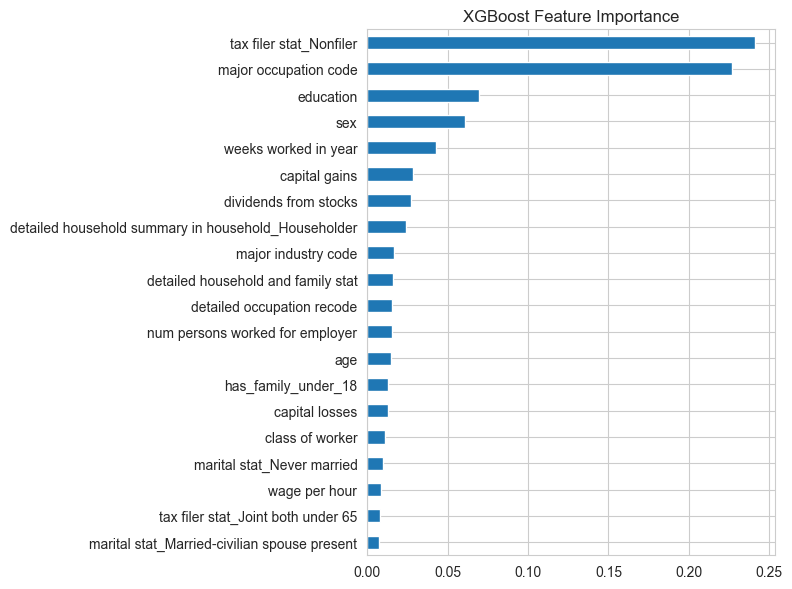

In [83]:
feat_names = getattr(search_xgb.best_estimator_, 'feature_names_in_', X_train.columns)
feat_imp = pd.Series(search_xgb.best_estimator_.feature_importances_, index=feat_names).sort_values(ascending=False)

feat_imp.head(20).plot(kind='barh', figsize=(8, 6))
plt.title("XGBoost Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [87]:
len(feat_imp)

49

In [89]:
low_importance = feat_imp[feat_imp < 0.001].index.tolist()
print(f"Dropping {len(low_importance)} low-importance features: {low_importance}")

Dropping 2 low-importance features: ['detailed household summary in household_Group Quarters- Secondary individual', 'detailed household summary in household_Child under 18 ever married']


In [90]:
X_train_pruned = X_train.drop(columns=low_importance)
X_test_pruned  = X_test.drop(columns=low_importance)

Retrain XGBoost on Pruned + Engineered Features

In [91]:
search_xgb_v2.fit(X_train_pruned, y_train)
print(search_xgb_v2.best_params_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
{'subsample': 0.8, 'scale_pos_weight': np.float64(15.113264688067838), 'reg_lambda': 1.0, 'reg_alpha': 1.0, 'n_estimators': 500, 'min_child_weight': 10, 'max_depth': 6, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.8, 'colsample_bylevel': 1.0}


In [92]:
thr_pruned = find_best_threshold(search_xgb_v2.best_estimator_, X_test_pruned, y_test)
results.append(evaluate("XGBoost Pruned", search_xgb_v2.best_estimator_, X_test_pruned, y_test, thr_pruned))


XGBoost Pruned  |  threshold=0.881
              precision    recall  f1-score   support

       <=50k       0.97      0.98      0.98     37429
        >50k       0.66      0.59      0.62      2476

    accuracy                           0.96     39905
   macro avg       0.82      0.78      0.80     39905
weighted avg       0.95      0.96      0.95     39905

ROC-AUC: 0.9529  |  PR-AUC: 0.6793


In [93]:
results_df = pd.DataFrame(results).sort_values('pr_auc', ascending=False)
results_df[['model', 'pr_auc', 'roc_auc', 'f1_minority', 'recall_minority', 'precision_minority', 'threshold']]

,model,pr_auc,roc_auc,f1_minority,recall_minority,precision_minority,threshold
2,XGBoost,0.682380,0.953138,0.623673,0.628837,0.618594,0.749367
5,XGBoost v2,0.680080,0.953184,0.627168,0.613489,0.641470,0.869037
3,LightGBM,0.679412,0.952762,0.622160,0.624798,0.619543,0.859169
6,XGBoost Pruned,0.679315,0.952884,0.622642,0.586430,0.663620,0.880970
4,XGBoost + SMOTE,0.670136,0.949994,0.609661,0.565832,0.660849,0.426115
1,Random Forest,0.626655,0.946492,0.587073,0.599758,0.574913,0.773514
0,Logistic Regression,0.586111,0.939166,0.557152,0.540388,0.574989,0.879308


In [102]:
proba  = search_xgb.best_estimator_.predict_proba(X_test)[:, 1]
y_pred = (proba >= 0.749).astype(int)

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[36467   962]
 [  919  1557]]


In [103]:
from catboost import CatBoostClassifier

model_cat = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    scale_pos_weight=SCALE_PW,
    eval_metric='PRAUC',
    random_seed=RANDOM_STATE,
    verbose=100
)
model_cat.fit(X_train, y_train)

0:	learn: 0.9002563	total: 45.5ms	remaining: 22.7s
100:	learn: 0.9458698	total: 3.66s	remaining: 14.5s
200:	learn: 0.9504197	total: 6.94s	remaining: 10.3s
300:	learn: 0.9544240	total: 10.3s	remaining: 6.83s
400:	learn: 0.9571038	total: 13.7s	remaining: 3.39s
499:	learn: 0.9591935	total: 17.1s	remaining: 0us


CatBoostClassifier(depth=6, eval_metric='PRAUC', iterations=500, learning_rate=0.05, random_seed=2401, scale_pos_weight=np.float64(15.113264688067838), verbose=100)

In [104]:
thr_cat = find_best_threshold(model_cat, X_test, y_test)
results.append(evaluate("CatBoost", model_cat, X_test, y_test, thr_cat))


CatBoost  |  threshold=0.868
              precision    recall  f1-score   support

       <=50k       0.97      0.98      0.98     37429
        >50k       0.63      0.61      0.62      2476

    accuracy                           0.95     39905
   macro avg       0.80      0.79      0.80     39905
weighted avg       0.95      0.95      0.95     39905

ROC-AUC: 0.9519  |  PR-AUC: 0.6714


In [105]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

estimators = [
    ('xgb',  search_xgb.best_estimator_),
    ('lgbm', search_lgbm.best_estimator_),
    ('rf',   search_rf.best_estimator_),
]

stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    cv=3,
    n_jobs=-1
)
stack.fit(X_train, y_train)

StackingClassifier(cv=3,
                   estimators=[('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=0.7, device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eval_metric='aucpr',
                                              feature_types=None,
                                              feature_weights=None, gamma=None,
                                              grow_policy=None,
                                              importance_type=None,
                                              interactio...
                               ('lgbm',
                                LGBMClassifier(class_weight='balanced',
                                               colsample_bytree=0.9,
                                               learning_rate=0.05, max_depth=6,
                                               min_child_samples=50,
                                               n_estimators=500, n_jobs=-1,
                                               random_state=2401, subsample=0.7,
                                               verbose=-1)),
                               ('rf',
                                RandomForestClassifier(class_weight='balanced',
                                                       max_depth=20,
                                                       min_samples_leaf=10,
                                                       n_jobs=-1,
                                                       random_state=2401))],
                   final_estimator=LogisticRegression(), n_jobs=-1)

In [106]:
thr_stack = find_best_threshold(stack, X_test, y_test)
results.append(evaluate("Stacking", stack, X_test, y_test, thr_stack))


Stacking  |  threshold=0.385
              precision    recall  f1-score   support

       <=50k       0.98      0.97      0.97     37429
        >50k       0.59      0.65      0.62      2476

    accuracy                           0.95     39905
   macro avg       0.78      0.81      0.80     39905
weighted avg       0.95      0.95      0.95     39905

ROC-AUC: 0.9535  |  PR-AUC: 0.6821


In [107]:
results

[{'model': 'Logistic Regression',
  'roc_auc': np.float64(0.9391660488392218),
  'pr_auc': np.float64(0.5861110849259572),
  'f1_minority': 0.5571517801374141,
  'recall_minority': 0.5403877221324718,
  'precision_minority': 0.5749892565535024,
  'threshold': np.float64(0.87930825676087)},
 {'model': 'Random Forest',
  'roc_auc': np.float64(0.9464918738336291),
  'pr_auc': np.float64(0.6266554506898853),
  'f1_minority': 0.5870725439810239,
  'recall_minority': 0.5997576736672051,
  'precision_minority': 0.5749128919860628,
  'threshold': np.float64(0.7735136856805354)},
 {'model': 'XGBoost',
  'roc_auc': np.float64(0.9531376390349142),
  'pr_auc': np.float64(0.6823802436665499),
  'f1_minority': 0.6236731423993591,
  'recall_minority': 0.6288368336025848,
  'precision_minority': 0.6185935637663885,
  'threshold': np.float32(0.74936706)},
 {'model': 'LightGBM',
  'roc_auc': np.float64(0.9527615635090861),
  'pr_auc': np.float64(0.6794122078023287),
  'f1_minority': 0.622159662175749,
 

In [ ]:
final_model = search_xgb.best_estimator_
final_threshold = 0.749

In [ ]:
import joblib
joblib.dump(final_model, 'final_xgb_classifier.pkl')
joblib.dump(encoder, 'target_encoder.pkl')

Models saved.


In [110]:
proba  = final_model.predict_proba(X_test)[:, 1]
y_pred = (proba >= final_threshold).astype(int)
print(classification_report(y_test, y_pred, target_names=['<=50k', '>50k']))
print(f"ROC-AUC : {roc_auc_score(y_test, proba):.4f}")
print(f"PR-AUC  : {average_precision_score(y_test, proba):.4f}")

              precision    recall  f1-score   support

       <=50k       0.98      0.97      0.97     37429
        >50k       0.62      0.63      0.62      2476

    accuracy                           0.95     39905
   macro avg       0.80      0.80      0.80     39905
weighted avg       0.95      0.95      0.95     39905

ROC-AUC : 0.9531
PR-AUC  : 0.6824


The best model is XG Boost


**ROC-AUC = 0.9531**:

This is excellent. It means if you randomly pick one true >50k person and one true <=50k person, your model gives the higher score to the >50k person about 95.31% of the time.

**PR-AUC = 0.6824**:

This is also strong, especially for imbalanced data (where >50k is the minority class). PR-AUC focuses on the positive class quality: